In [1]:
import glob

from figures import *
from laser import *
from pipeline import *

# load spectrum
data_root = "/datax/scratch/ktp/carmenes-lasers/"
dir_list = glob.glob(data_root + "spectra/extracted/*")

diridx = 10

GOAL: inject lsf shaped laser into a spectrum

In [2]:
from load_data import load_star
save_dir = dir_list[diridx]

# load in data
(spec_arr, 
 cont_arr, 
 sigma_arr, 
 wave_arr, 
 obj, 
 ra, 
 dec, 
 date_arr, 
 exptime_arr, 
 airm_arr, 
 bary_corr_arr) = load_star(save_dir, print_headers=False, print_flux_headers=False)

# load in resamples
new_wave_path = save_dir + "/resampled_wave.npy"
new_spec_path = save_dir + "/resampled_spec.npy"
new_sig_path = save_dir + "/resampled_sig.npy"

new_wave_arr = np.load(new_wave_path, allow_pickle=True)
new_spec_arr = np.load(new_spec_path, allow_pickle=True)
new_sig_arr = np.load(new_sig_path, allow_pickle=True)

# load in polyfits
results = resample_and_fit(wave_arr, 
                    spec_arr, 
                    sigma_arr,
                    bary_corr_arr, 
                    save_dir, 
                    criterion="AIC")

(new_wave_arr,
               normalized_spec, 
               normalized_sig,
               poly_arr_best, 
               nopoly_arr_best, 
               bin_midpts_arr_best, 
               bin_meds_arr_best, 
               bic_vals, 
               deg_vals, 
               high_std_mask
) = results

processing degree 1
processing degree 2
processing degree 3
processing degree 4
processing degree 5


(61, 11)


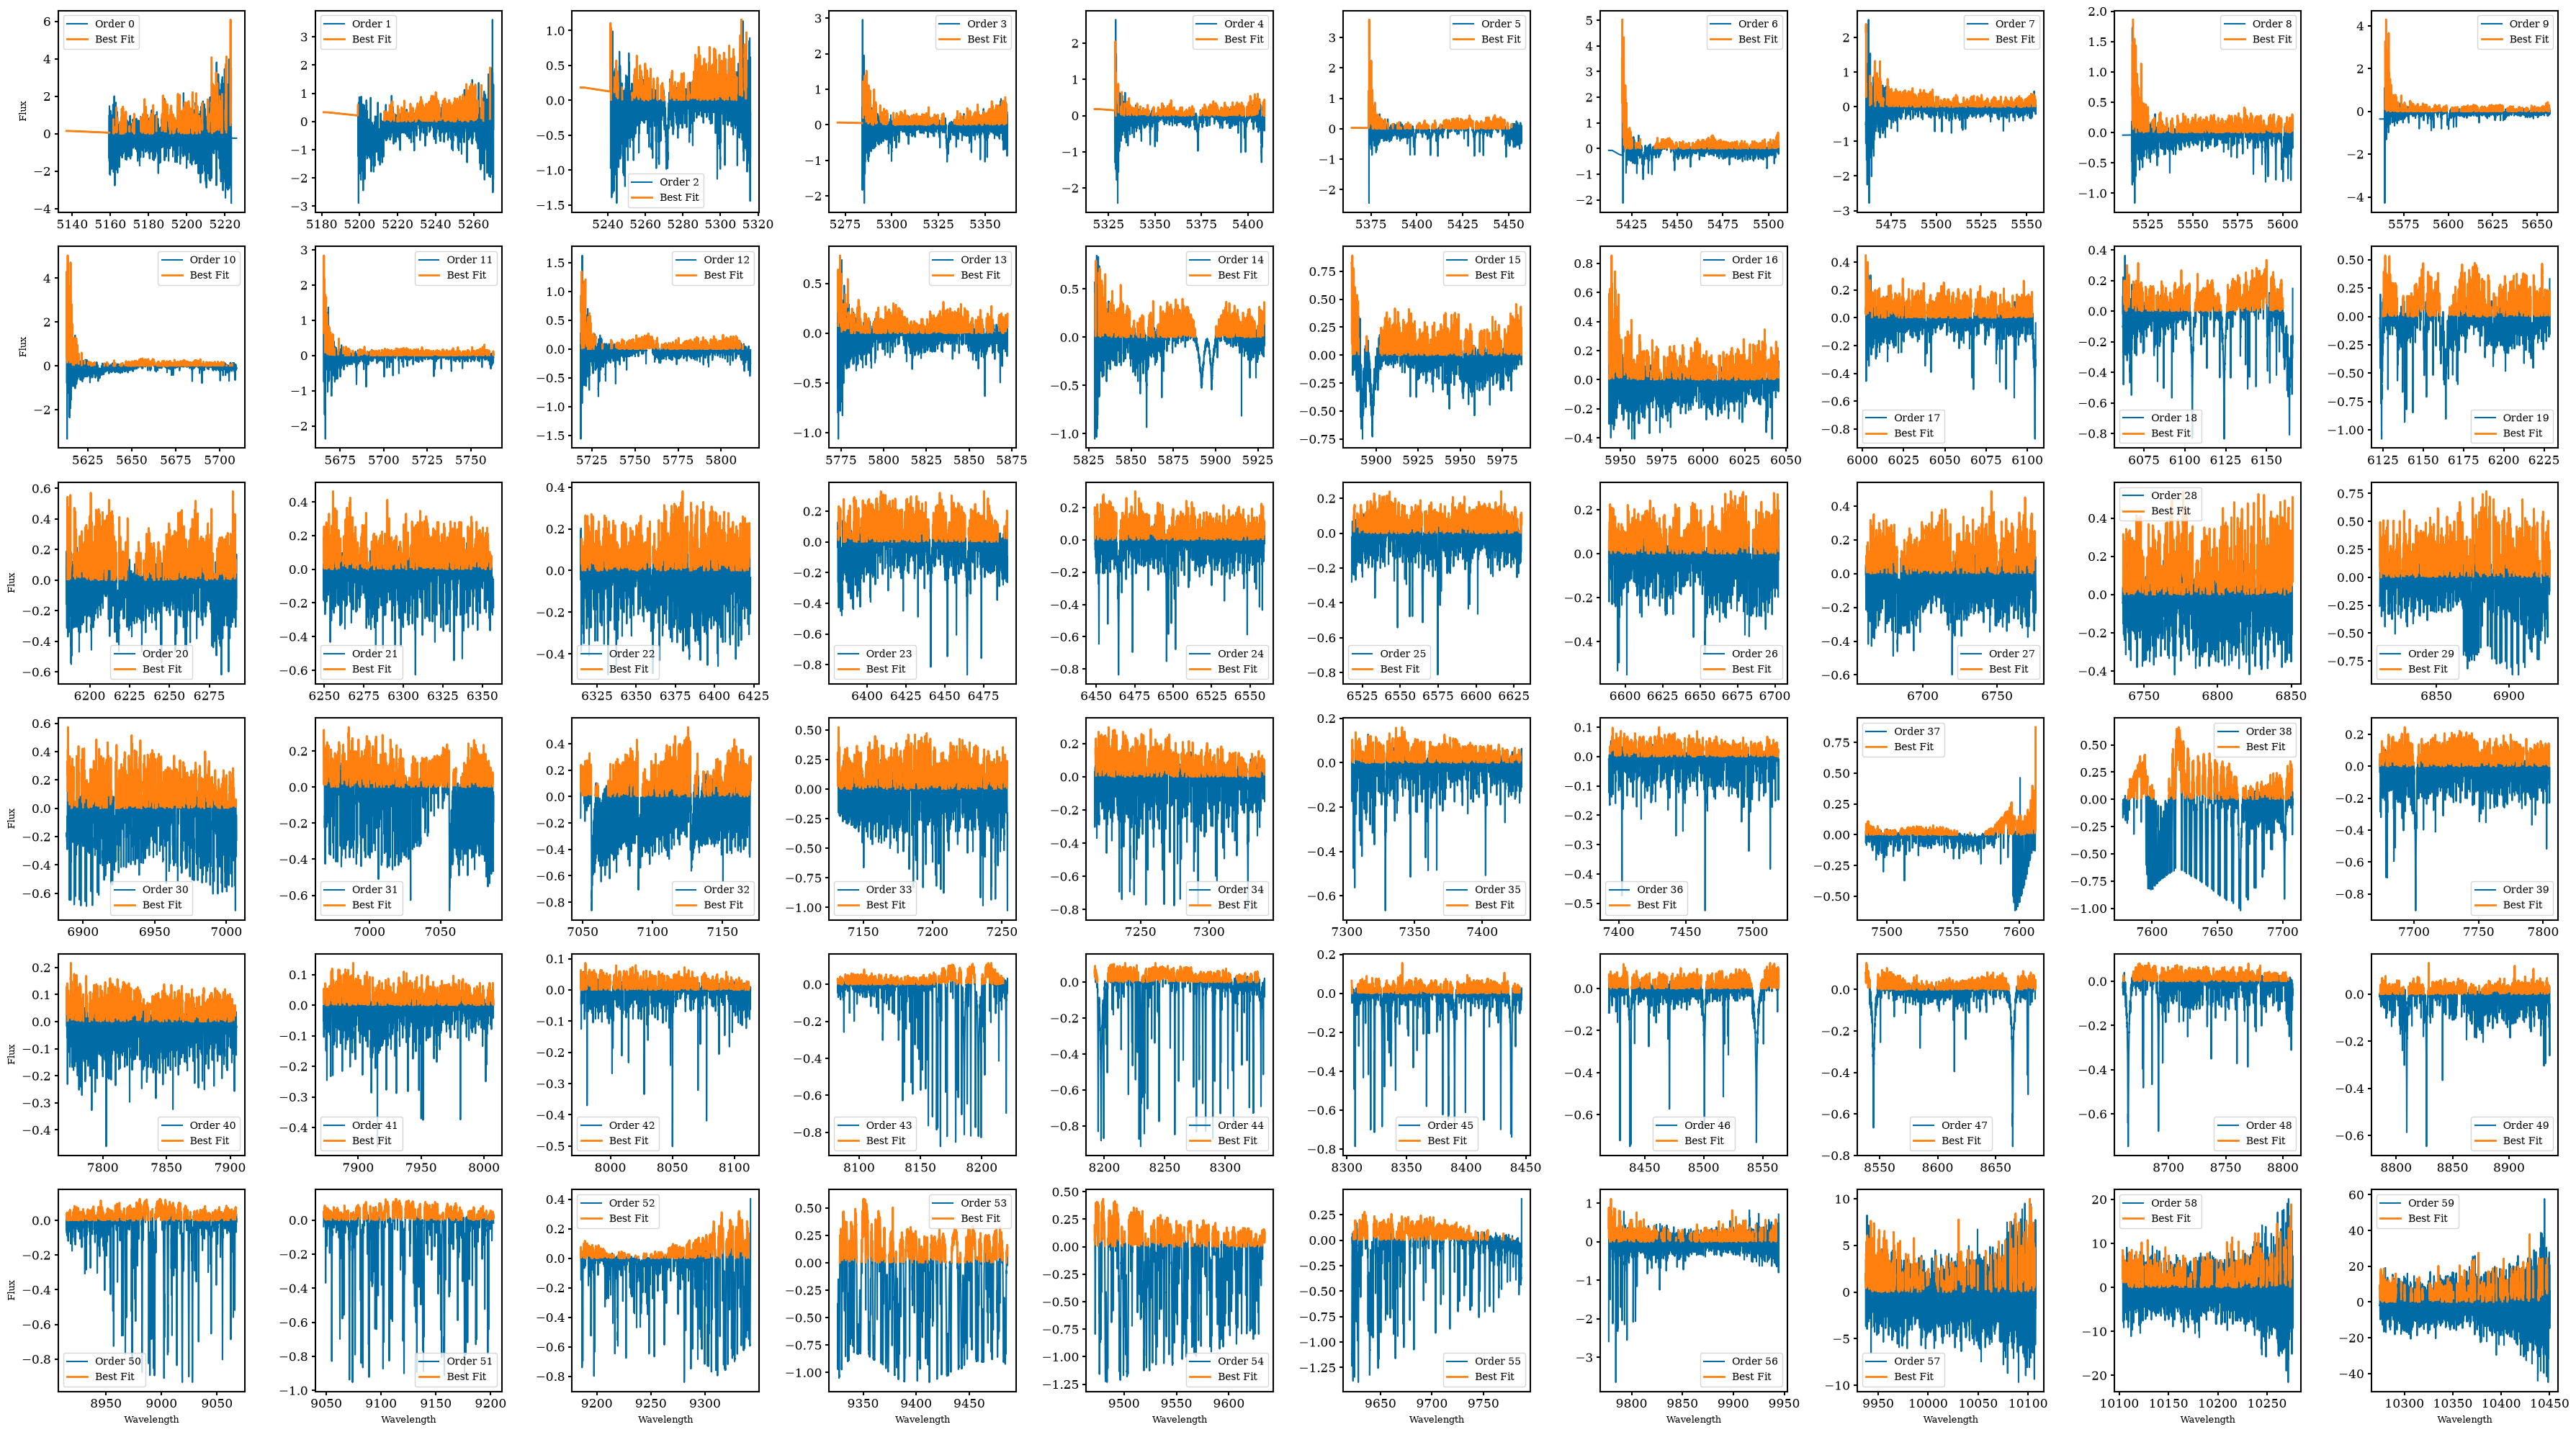

In [3]:

## code to identify consecutive n pixels above polyfit baseline
## FWHM from Nagel+ 2023: 2.5 - 4 px --> could get this from converting wl values


def med_abs_dev(x):
    med = np.nanmedian(x)
    abs_dev = np.abs(x - med)
    mad = np.nanmedian(abs_dev)
    return mad

positive_sub_arr_filtered, median_of_medians = identify_peaks(normalized_spec, poly_arr_best, n=3)

print(median_of_medians.shape)

# spectra are not flat because the polyfit is subtracted
# best fit is a misnomer, this is positive lines 
plot_spectra_ords(new_wave_arr, 
                 normalized_spec - poly_arr_best, poly_arr=positive_sub_arr_filtered, figsize=(36, 20))

plt.show()

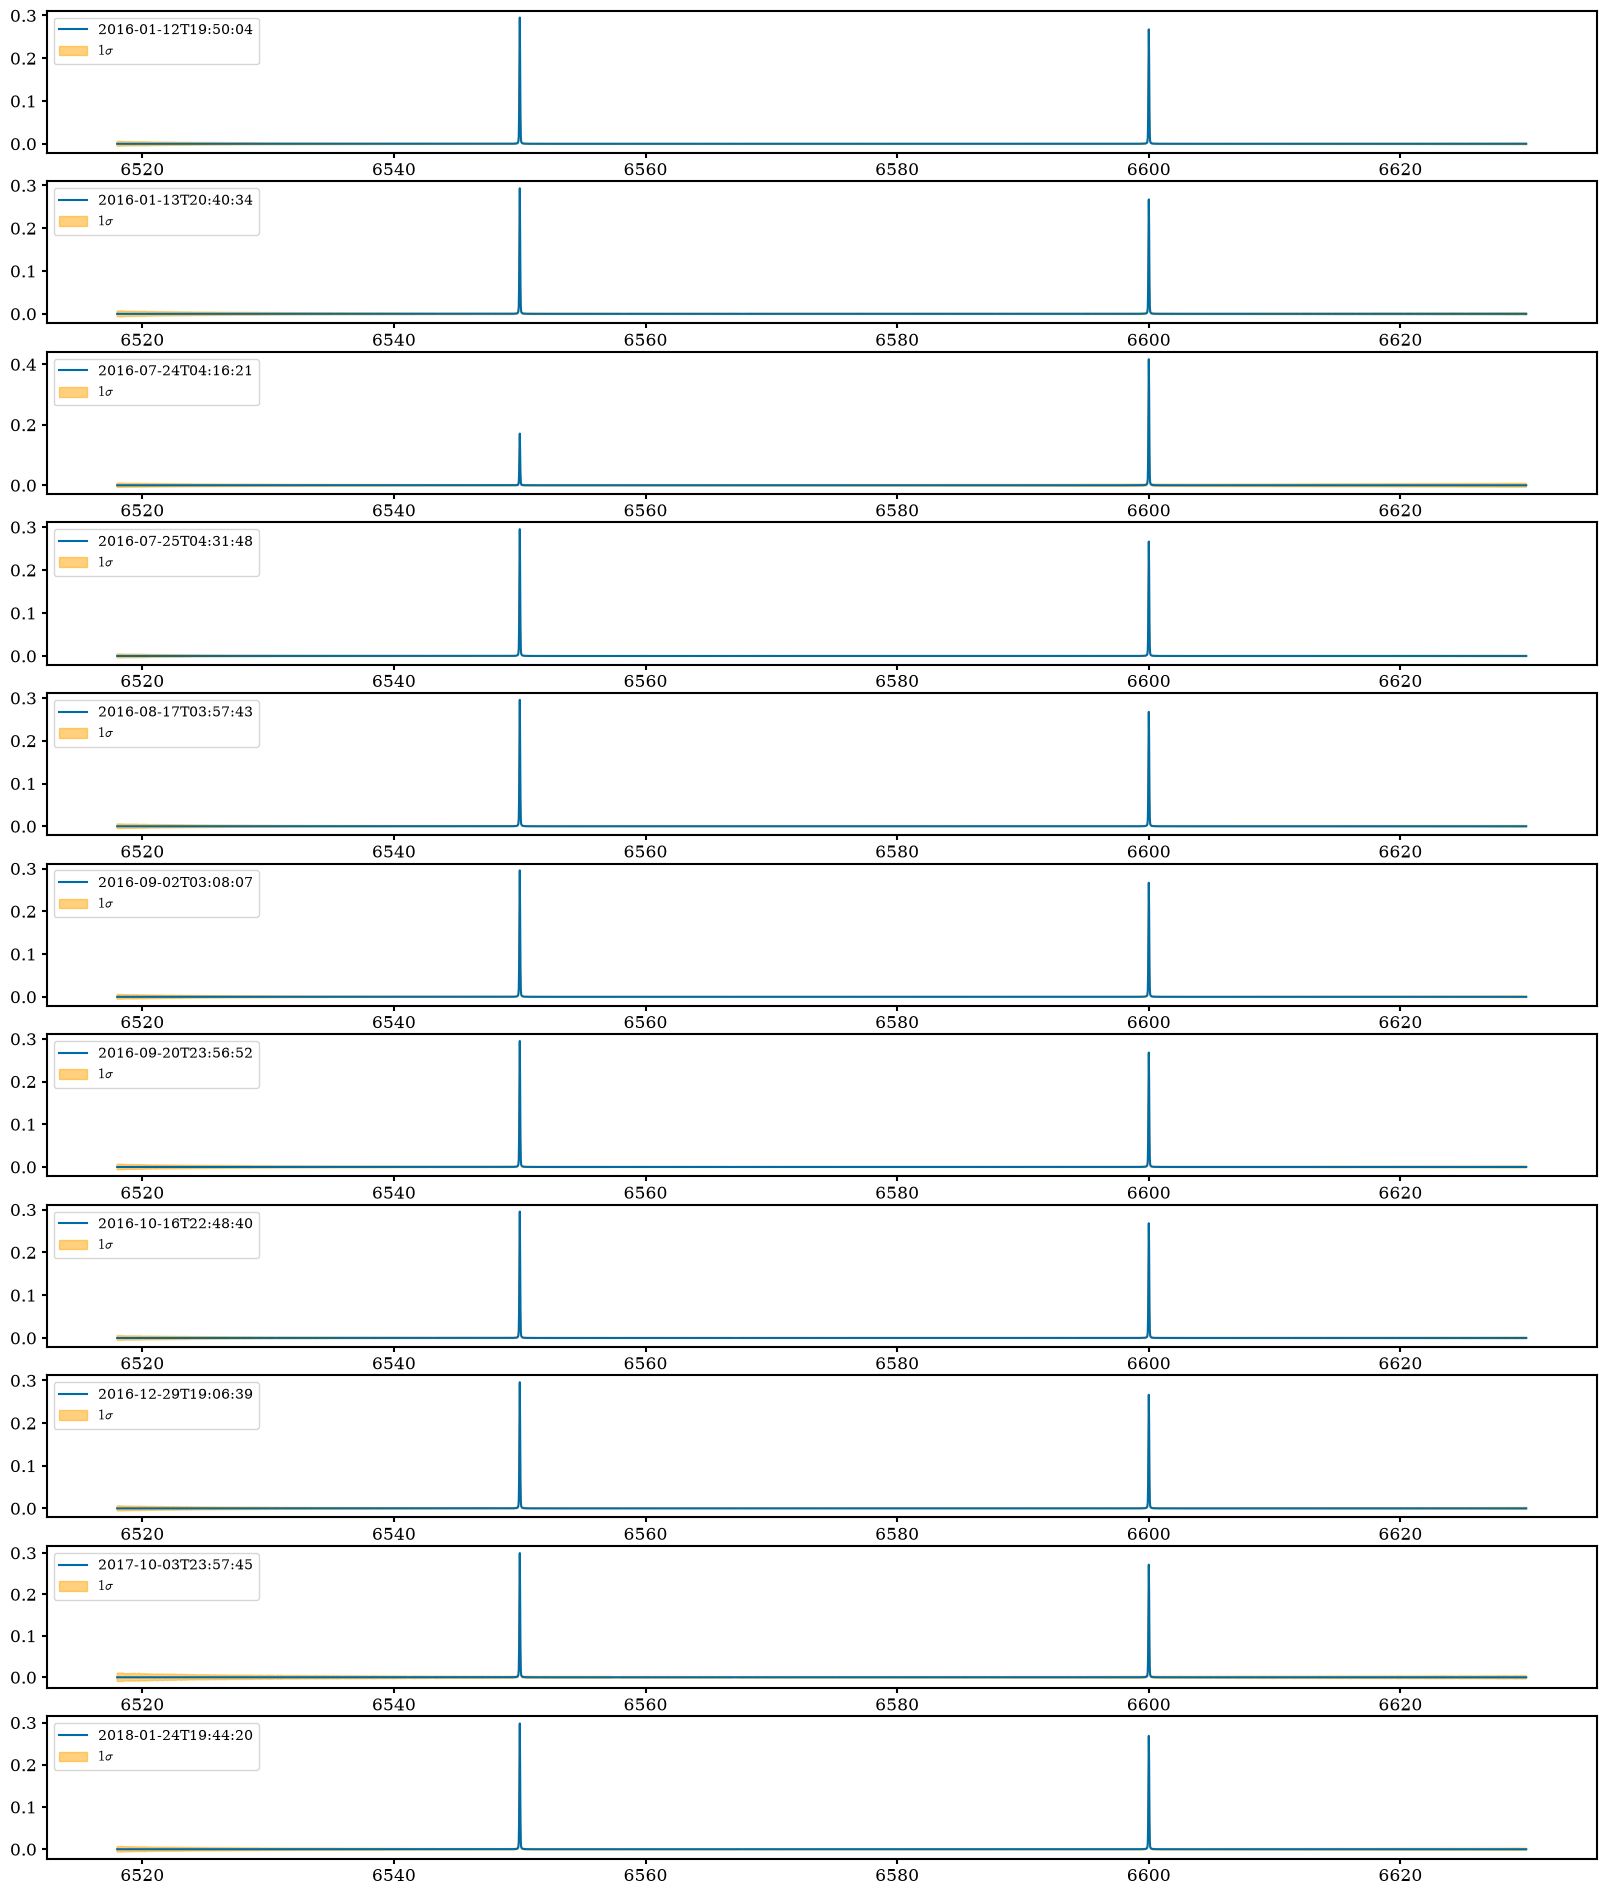

In [4]:
laser_arr = make_laser_arr(new_wave_arr, normalized_spec, poly_arr_best)

n_obs_range = [0, spec_arr.shape[2]]
ordidx = 25

plot_spectra_obs(n_obs_range, 
                 new_wave_arr, 
                 laser_arr, 
                 sigma_arr, 
                 date_arr, ordidx)
plt.show()

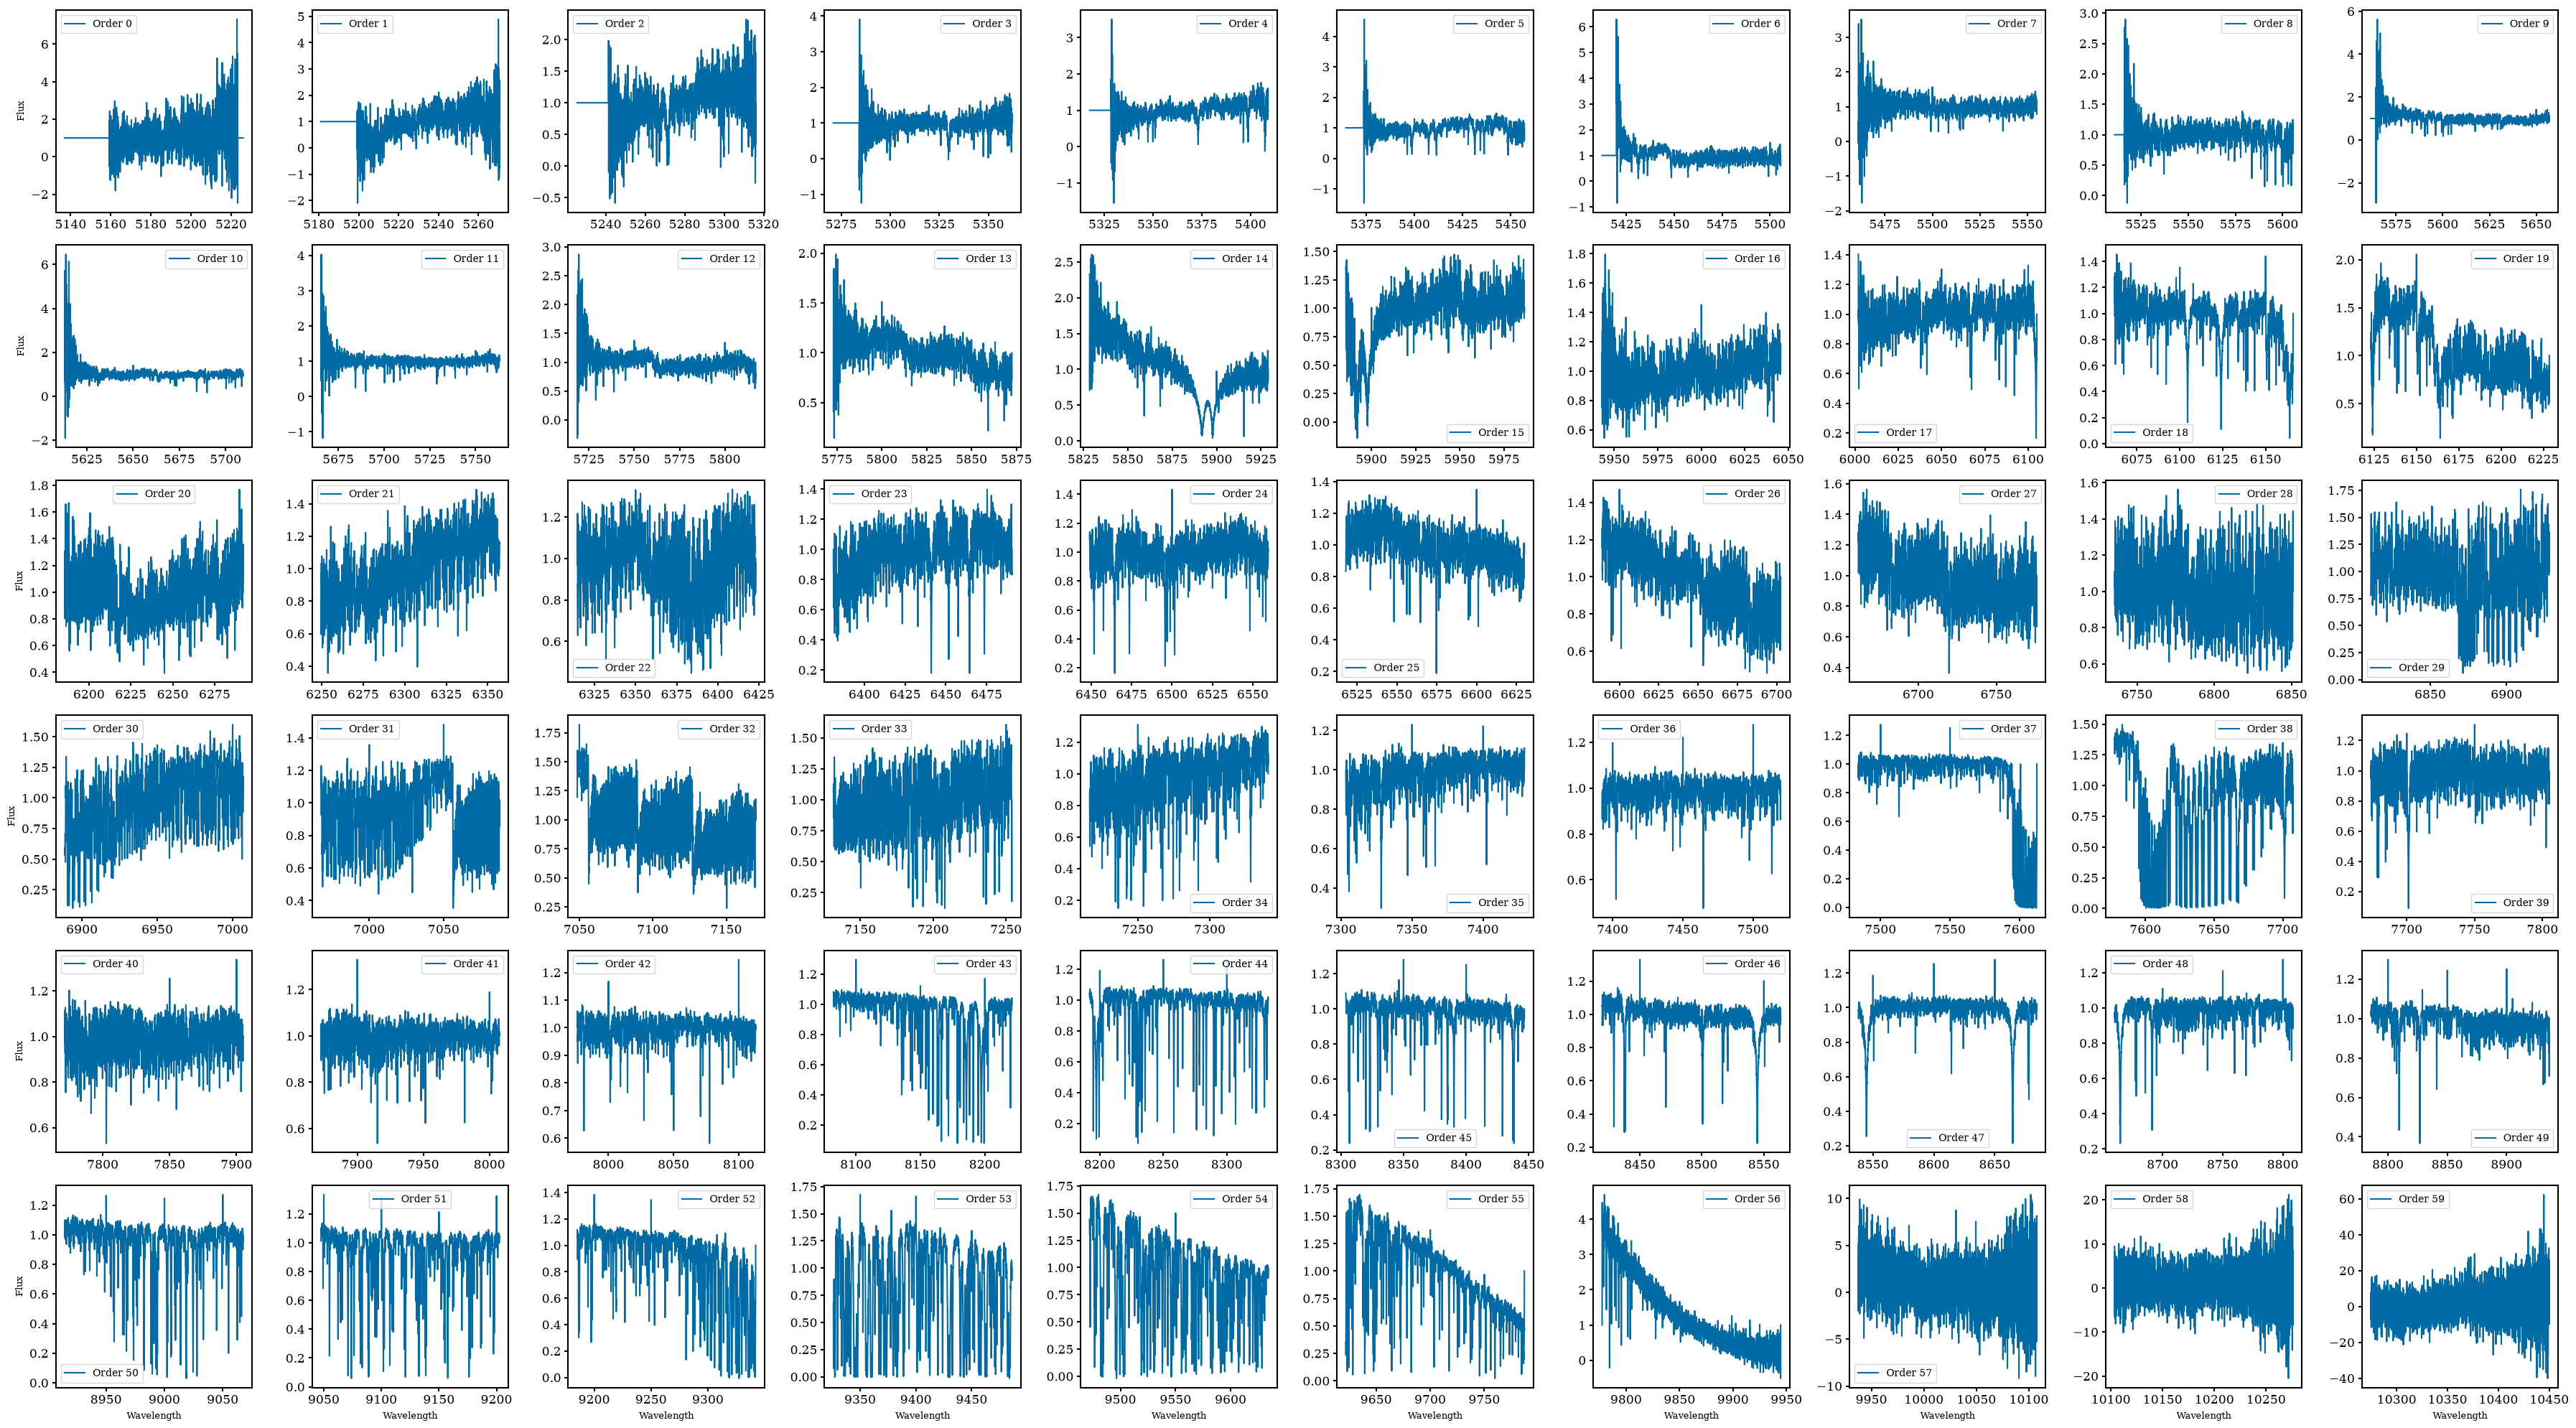

In [5]:
normalized_laser_arr = laser_arr / poly_arr_best

plot_spectra_ords(new_wave_arr, 
                 normalized_laser_arr+ normalized_spec, figsize=(36, 20))

plt.show()

In [6]:
# spec_arr dims are ord, wav, obs
ordidx = 25
n_obs = [0, spec_arr.shape[2]] #

start, end = n_obs # end is exclusive
idxs = range(start, min(end, spec_arr.shape[2]))  

wl = 6560 # angstrom
laser = lsf_per_wav(wave_grid[ordidx], wl, amplitude_L=0.25)

print(wave_arr[ordidx, :, 0].min(), wave_arr[ordidx, :, 0].max())
print(wave_grid[ordidx].min(), wave_grid[ordidx].max())

## injection should match doppler shift
fig, axs = plt.subplots(len(idxs), figsize=(20, 24))
fig.suptitle(f"{obj[0]} Order {ordidx}")

axs_i = 0
for i in idxs:
    spectra = spec_arr[ordidx, :, i]
    sigma = sigma_arr[ordidx, :, i]
    wg = wave_grid[ordidx]

    axs[axs_i].plot(wg, spectra + laser, label = f"{date_arr[i]}")
    axs[axs_i].fill_between(wg, spectra-sigma, spectra+sigma, alpha=0.5, color="orange", label="$1\\sigma$")
    axs[axs_i].vlines(6564.6, 0, 0.1, color="red", label="H$\\alpha$")

    axs[axs_i].legend(loc="upper left")

    axs_i+=1

plt.show()

NameError: name 'wave_grid' is not defined

In [ ]:
fig, axs = plt.subplots(len(idxs), figsize=(20, 24))
fig.suptitle(f"{obj[0]} Order {ordidx}")

axs_i = 0
for i in idxs:
    spectra = spec_arr[ordidx, :, i]
    sigma = sigma_arr[ordidx, :, i]
    wg = wave_arr[ordidx, :, i]

    axs[axs_i].plot(wg, spectra + laser, label = f"{date_arr[i]}")
    axs[axs_i].fill_between(wg, spectra-sigma, spectra+sigma, alpha=0.5, color="orange", label="$1\\sigma$")
    axs[axs_i].vlines(6564.6, 0, 0.1, color="red", label="H$\\alpha$")

    axs[axs_i].legend(loc="upper left")

    axs_i+=1

plt.show()

In [ ]:
# load in the spectra
from astropy.io.votable import parse
from astropy.table import Table

# to ignore "Angstroms" as an outdated label
import warnings
from astropy.units import UnitsWarning
warnings.filterwarnings("ignore", category=UnitsWarning)

data_root = "/datax/scratch/ktp/carmenes-lasers/test_data/"

lutyen_path = data_root + "carmenes_data_J07274+052_car-20160108T01h39m51s-sci-gtoc-vis_A.vot"
vot = parse(lutyen_path)

spec_ords, flux_ords, cont_ords, err_ords = [], [], [], []
n_tables = 1
for tab in vot.iter_tables():
    table = tab.to_table()

    if n_tables > 1:
        spec_ords.append(table[f'spectral-{n_tables:02d}'])
        flux_ords.append(table[f'flux-{n_tables:02d}'])
        cont_ords.append(table[f'cont_flux-{n_tables:02d}'])
        err_ords.append(table[f'err_flux-{n_tables:02d}'])
    else:
        spec_ords.append(table['spectral'])
        flux_ords.append(table['flux'])
        cont_ords.append(table['cont_flux'])
        err_ords.append(table['err_flux'])
    n_tables+=1

In [ ]:
arb = 0
spec, flux = spec_ords[arb], flux_ords[arb]

n_sections = 10

max_diff = simple_threshold(flux, 3)

spec_sections, flux_sections = np.array_split(spec, n_sections), np.array_split(flux, n_sections)

spec_pk_sec, flx_pk_sec = [], []
for i, specsec in enumerate(spec_sections):   
    peaks, _ = find_peaks(flux_sections[i], max_diff)
    spec_pk_sec.append(specsec[peaks])
    flx_pk_sec.append(flux_sections[i][peaks])

fig, axs = plt.subplots(n_sections, figsize=(20,20))
plot_spectra_elike(fig, axs, spec, flux, n_sections, title=f"Lutyen's Star w/ Peaks, Ord. {arb}")
for i in range(n_sections):
    axs[i].scatter(spec_pk_sec[i], flx_pk_sec[i], color='red')

In [ ]:
i = 1
fwhm_arr = full_width_half_max(spec_sections[i], 
                               flux_sections[i],
                               spec_pk_sec[i], 
                               flx_pk_sec[i],
                               0.01
                              )

In [ ]:
# lets do this on a full order

arb = 4
spec, flux = spec_ords[arb], flux_ords[arb]

def spec_to_fwhms(spec, flux, sigma, max_diff=0.01, verbose=False):
    threshold = simple_threshold(flux, sigma) # get the std threshold

    peaks, _ = find_peaks(flux, threshold) # get peaks above threshold 
    spec_pks, flx_pks = spec[peaks], flux[peaks]
    
    fwhms = full_width_half_max(spec, flux, spec_pks, flx_pks, max_diff, verbose=verbose) # fwhm of peaks

    return fwhms

fwhms = spec_to_fwhms(spec, flux, 3)

# pixel - wavelength function to convert fwhm to pixels
pixels = np.arange(0, len(spec), 1)
fit_coeffs = np.polyfit(pixels, spec, 1)
spec_of_px = np.poly1d(fit_coeffs)

px_max = 4
px_min = 2.5

wl_max = spec_of_px(px_max) - spec_of_px(0)
wl_min = spec_of_px(px_min) - spec_of_px(0)

print(f'1 px = {spec_of_px(1) - spec_of_px(0)} ang')
print(f"wl range of fwhm of lsf {wl_min, wl_max}")

print(f"There are {len(fwhms[fwhms < wl_max])} peaks narrower than the max LSF")
print(f"There are {len(fwhms[fwhms < wl_max])} peaks narrower than the max LSF")

print(fwhms[:5])

In [ ]:
## take a peak, make a postage stamp of it and plot lsf on top
        
# take a peak
peak_idx = 5
buffer = 1

threshold = simple_threshold(flux, 3)
peaks, _ = find_peaks(flux, threshold)

lambda_c = spec[peaks][peak_idx]
flx_peak = flux[peaks][peak_idx]

# cut to around the peak
spec_seg_argmin = np.argmin(np.abs(spec - (lambda_c - buffer)))
spec_seg_argmax = np.argmin(np.abs(spec - (lambda_c + buffer)))

flx_seg = flux[spec_seg_argmin:spec_seg_argmax]
flx_seg_median = np.median(flx_seg)

# get lsf
lsf = lsf_per_wav(spec, np.array([lambda_c]), amplitude_L=flx_peak)

# plotting
plt.figure(figsize=(15, 5))
plt.plot(spec, flux, label="Spectrum")
plt.plot(spec, flx_seg_median + lsf, label="LSF")
plt.scatter(lambda_c, flx_peak, color='red')
plt.xlim(lambda_c - buffer, lambda_c + buffer)
plt.ylim(flx_seg_median - 0.25*flx_peak, flx_seg_median + 0.25*flx_peak)
plt.legend()
plt.xlabel('Angstroms')
plt.ylabel('Normalized Flux')
plt.show()

In [ ]:

# plotting
plt.figure(figsize=(15, 5))
plt.plot(spec, flux, label="Spectrum")
plt.plot(spec, flx_seg_median + lsf, label="LSF")
plt.plot(spec, flux+ lsf, label="coadded")

plt.scatter(lambda_c, flx_peak, color='red')
plt.xlim(lambda_c - buffer, lambda_c + buffer)
# plt.ylim(flx_seg_median - 0.25*flx_peak, flx_seg_median + 0.25*flx_peak)
plt.legend()
plt.xlabel('Angstroms')
plt.ylabel('Normalized Flux')
plt.show()